In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.signal import welch
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import pdist

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

try:
    import hdbscan
    HDBSCAN_AVAILABLE = True
except Exception:
    HDBSCAN_AVAILABLE = False



In [1]:
pip install hdbscan


  Using cached hdbscan-0.8.42-cp310-cp310-win_amd64.whl.metadata (15 kB)
Using cached hdbscan-0.8.42-cp310-cp310-win_amd64.whl (685 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# -------------------------
# Load calcium traces
# -------------------------

def load_traces_from_link_table(db_csv_path, trace_filename='calTraceDF.csv', link_col='Link'):
    """
    Reads a table with a folder path per row (default column 'Link').
    Loads one calcium trace file per folder.
    Returns:
      traces_list: list[np.ndarray]
      meta_df: pd.DataFrame with row metadata
    """
    db = pd.read_csv(db_csv_path)
    if link_col not in db.columns:
        raise ValueError(f"Column '{link_col}' not found in {db_csv_path}")

    traces = []
    meta = []
    for i, row in db.iterrows():
        folder = str(row[link_col])
        trace_path = os.path.join(folder, trace_filename)
        if not os.path.exists(trace_path):
            continue

        tr = pd.read_csv(trace_path).to_numpy().astype(float).ravel()
        if tr.size == 0:
            continue

        traces.append(tr)
        rec = {'row_idx': i, 'folder': folder, 'trace_path': trace_path, 'n_samples': int(tr.size)}
        for c in db.columns:
            if c not in rec:
                rec[c] = row[c]
        meta.append(rec)

    if len(traces) == 0:
        raise RuntimeError('No traces were loaded.')

    return traces, pd.DataFrame(meta)


def load_traces_from_paths(trace_paths):
    traces = []
    meta = []
    for i, pth in enumerate(trace_paths):
        tr = pd.read_csv(pth).to_numpy().astype(float).ravel()
        if tr.size == 0:
            continue
        traces.append(tr)
        meta.append({'row_idx': i, 'trace_path': pth, 'folder': os.path.dirname(pth), 'n_samples': int(tr.size)})
    if len(traces) == 0:
        raise RuntimeError('No traces were loaded.')
    return traces, pd.DataFrame(meta)



In [4]:
# -------------------------
# Feature extraction
# -------------------------

def _nan_interp(x):
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return x
    m = np.isfinite(x)
    if m.all():
        return x
    idx = np.arange(x.size)
    if m.sum() == 0:
        return np.zeros_like(x)
    if m.sum() == 1:
        return np.full_like(x, x[m][0])
    y = x.copy()
    y[~m] = np.interp(idx[~m], idx[m], x[m])
    return y


def _robust_z(x):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    sigma = 1.4826 * mad if mad > 1e-12 else np.nanstd(x)
    sigma = sigma if sigma > 1e-12 else 1.0
    return (x - med) / sigma


def _autocorr_decay_features(x, sr, max_lag_s=10.0):
    x = np.asarray(x, dtype=float)
    x = _nan_interp(x)
    x = x - np.mean(x)
    if x.size < 4:
        return {'acf_tau_1e_s': np.nan, 'acf_auc': np.nan}

    ac = np.correlate(x, x, mode='full')
    ac = ac[ac.size // 2:]
    if ac[0] <= 0:
        return {'acf_tau_1e_s': np.nan, 'acf_auc': np.nan}
    ac = ac / ac[0]

    max_lag = min(len(ac) - 1, int(round(max_lag_s * sr)))
    lags = np.arange(max_lag + 1) / sr
    ac_sub = ac[:max_lag + 1]

    below = np.where(ac_sub <= (1 / np.e))[0]
    tau_1e = lags[below[0]] if len(below) > 0 else np.nan
    auc = np.trapz(np.clip(ac_sub, 0, None), lags)

    return {'acf_tau_1e_s': float(tau_1e) if np.isfinite(tau_1e) else np.nan,
            'acf_auc': float(auc)}


def _psd_features(x, sr):
    x = np.asarray(x, dtype=float)
    x = _nan_interp(x)
    if x.size < 8:
        return {
            'psd_total_power': np.nan,
            'psd_centroid_hz': np.nan,
            'psd_entropy': np.nan,
            'psd_rel_low': np.nan,
            'psd_rel_mid': np.nan,
            'psd_rel_high': np.nan,
        }

    nperseg = min(1024, max(64, x.size // 8))
    f, pxx = welch(x, fs=sr, nperseg=nperseg)
    pxx = np.clip(pxx, 0, None)

    total = np.trapz(pxx, f) if len(f) > 1 else np.nan
    if not np.isfinite(total) or total <= 0:
        total = np.nan

    centroid = np.trapz(f * pxx, f) / np.trapz(pxx, f) if np.isfinite(total) else np.nan

    pnorm = pxx / np.sum(pxx) if np.sum(pxx) > 0 else np.full_like(pxx, np.nan)
    ent = -np.nansum(pnorm * np.log2(np.clip(pnorm, 1e-12, None)))

    # bands in Hz (tune if needed for your calcium sampling / kinetics)
    bands = {
        'low': (0.01, 0.10),
        'mid': (0.10, 0.50),
        'high': (0.50, 2.00),
    }

    rel = {}
    for k, (a, b) in bands.items():
        m = (f >= a) & (f < b)
        bp = np.trapz(pxx[m], f[m]) if np.any(m) else 0.0
        rel[f'psd_rel_{k}'] = (bp / total) if np.isfinite(total) and total > 0 else np.nan

    return {
        'psd_total_power': float(total) if np.isfinite(total) else np.nan,
        'psd_centroid_hz': float(centroid) if np.isfinite(centroid) else np.nan,
        'psd_entropy': float(ent) if np.isfinite(ent) else np.nan,
        **rel,
    }


def extract_trace_features(trace, sr):
    x = np.asarray(trace, dtype=float)
    x = _nan_interp(x)
    z = _robust_z(x)

    feats = {
        'std': float(np.nanstd(x)),
        'skew': float(stats.skew(x, nan_policy='omit', bias=False)) if x.size > 2 else np.nan,
        'kurtosis': float(stats.kurtosis(x, nan_policy='omit', fisher=True, bias=False)) if x.size > 3 else np.nan,
        'fraction_active': float(np.nanmean(z > 2.0)),
    }

    feats.update(_autocorr_decay_features(x, sr=sr, max_lag_s=10.0))
    feats.update(_psd_features(x, sr=sr))
    return feats


def build_feature_table(traces_list, sr):
    rows = []
    for i, tr in enumerate(traces_list):
        f = extract_trace_features(tr, sr=sr)
        f['trace_idx'] = i
        rows.append(f)
    feat_df = pd.DataFrame(rows)
    return feat_df



In [5]:
# -------------------------
# Dimensionality reduction + clustering
# -------------------------

def run_pca_and_clustering(feature_df, n_pca_components=0.90, n_hier_clusters=4,
                           hdbscan_min_cluster_size=10, hdbscan_min_samples=3):
    feat_cols = [c for c in feature_df.columns if c != 'trace_idx']
    X = feature_df[feat_cols].copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True))

    scaler = StandardScaler()
    Xz = scaler.fit_transform(X)

    pca = PCA(n_components=n_pca_components, random_state=0)
    Xp = pca.fit_transform(Xz)

    # Hierarchical clustering (Ward on PCA)
    Z = linkage(Xp, method='ward')
    hier_labels = fcluster(Z, t=n_hier_clusters, criterion='maxclust')

    # HDBSCAN on PCA
    if HDBSCAN_AVAILABLE:
        hdb = hdbscan.HDBSCAN(min_cluster_size=hdbscan_min_cluster_size,
                              min_samples=hdbscan_min_samples)
        hdb_labels = hdb.fit_predict(Xp)
    else:
        hdb_labels = np.full(Xp.shape[0], -1, dtype=int)

    out = feature_df.copy()
    out['hier_cluster'] = hier_labels
    out['hdbscan_cluster'] = hdb_labels

    return {
        'feature_table': out,
        'Xz': Xz,
        'Xpca': Xp,
        'pca': pca,
        'scaler': scaler,
        'linkage': Z,
    }



In [7]:
# -------------------------
# Visualization
# -------------------------

def _resample_trace(x, n_points=1500):
    x = np.asarray(x, dtype=float)
    x = _nan_interp(x)
    if x.size == n_points:
        return x
    old = np.linspace(0, 1, x.size)
    new = np.linspace(0, 1, n_points)
    return np.interp(new, old, x)


def plot_pca_scatter(Xpca, labels, title='PCA scatter'):
    plt.figure(figsize=(6, 5))
    uniq = np.unique(labels)
    for lb in uniq:
        m = labels == lb
        name = 'noise' if lb == -1 else f'cluster {lb}'
        plt.scatter(Xpca[m, 0], Xpca[m, 1], s=24, alpha=0.8, label=name)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(title)
    plt.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_dendrogram(Z, truncate_mode='lastp', p=30):
    plt.figure(figsize=(8, 4))
    dendrogram(Z, truncate_mode=truncate_mode, p=p)
    plt.title('Hierarchical clustering dendrogram')
    plt.tight_layout()
    plt.show()


def plot_cluster_average_traces(traces_list, labels, sr, title='Cluster-average traces',
                                n_points=1500, min_cluster_size=3):
    labels = np.asarray(labels)
    resampled = np.vstack([_resample_trace(t, n_points=n_points) for t in traces_list])
    t = np.arange(n_points) / sr

    clusters = [c for c in np.unique(labels) if c != -1]
    clusters = [c for c in clusters if np.sum(labels == c) >= min_cluster_size]
    if len(clusters) == 0:
        print('No clusters with enough traces to plot.')
        return

    plt.figure(figsize=(10, 5))
    for c in clusters:
        m = labels == c
        avg = np.nanmean(resampled[m], axis=0)
        sem = np.nanstd(resampled[m], axis=0) / np.sqrt(np.sum(m))
        plt.plot(t, avg, lw=2, label=f'cluster {c} (n={np.sum(m)})')
        plt.fill_between(t, avg - sem, avg + sem, alpha=0.2)

    plt.xlabel('Resampled time (s)')
    plt.ylabel('Calcium signal')
    plt.title(title)
    plt.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()



In [8]:
# -------------------------
# Run pipeline
# -------------------------

# Option A: from a table with folder links
DB_PATH = r"Z:\Adam-Lab-Shared\Data\Michal_Rubin\Dendrites\SST_Final.csv"
CAL_SR = 30.0
traces_list, meta_df = load_traces_from_link_table(DB_PATH, trace_filename='calTraceDF.csv', link_col='Link')

# # Option B: explicit paths
# trace_paths = glob.glob(r"Z:\Adam-Lab-Shared\Data\Michal_Rubin\**\calTraceDF.csv", recursive=True)
# traces_list, meta_df = load_traces_from_paths(trace_paths)
# CAL_SR = 30.0

print(f'Loaded traces: {len(traces_list)}')

feat_df = build_feature_table(traces_list, sr=CAL_SR)
res = run_pca_and_clustering(
    feat_df,
    n_pca_components=0.90,
    n_hier_clusters=4,
    hdbscan_min_cluster_size=10,
    hdbscan_min_samples=3,
)

cluster_df = meta_df.merge(res['feature_table'], left_on='row_idx', right_on='trace_idx', how='inner')
cluster_df.head()



Loaded traces: 82


C:\Users\owner\AppData\Local\Temp\ipykernel_9172\481650319.py:50: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(np.clip(ac_sub, 0, None), lags)
C:\Users\owner\AppData\Local\Temp\ipykernel_9172\481650319.py:73: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total = np.trapz(pxx, f) if len(f) > 1 else np.nan
C:\Users\owner\AppData\Local\Temp\ipykernel_9172\481650319.py:77: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  centroid = np.trapz(f * pxx, f) / np.trapz(pxx, f) if np.isfinite(total) else np.nan
C:\Users\owner\AppData\Local\Temp\ipykernel_9172\481650319.py:92: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  b

,row_idx,folder,trace_path,n_samples,Mice,Imaging_Seshion,Imaging_Date,Num_of_ROI,Notes,Link,...,acf_auc,psd_total_power,psd_centroid_hz,psd_entropy,psd_rel_low,psd_rel_mid,psd_rel_high,trace_idx,hier_cluster,hdbscan_cluster
0,0,Z:\Adam-Lab-Shared\Data\Michal_Rubin\srugc17\X...,Z:\Adam-Lab-Shared\Data\Michal_Rubin\srugc17\X...,3600,srugc17-xb,17/06/2025,17/06/2025,cell1,NaN,Z:\Adam-Lab-Shared\Data\Michal_Rubin\srugc17\X...,...,1.437723,0.039534,1.662143,4.712402,0.0,0.229106,0.101743,0,2,-1
1,1,Z:\Adam-Lab-Shared\Data\Michal_Rubin\srugc17\X...,Z:\Adam-Lab-Shared\Data\Michal_Rubin\srugc17\X...,3601,srugc17-xb,14/07/2025,14/07/2025,cell0,NaN,Z:\Adam-Lab-Shared\Data\Michal_Rubin\srugc17\X...,...,2.205604,0.034584,1.856738,4.959578,0.0,0.392937,0.102297,1,2,-1
2,2,Z:\Adam-Lab-Shared\Data\Michal_Rubin\srugc17\X...,Z:\Adam-Lab-Shared\Data\Michal_Rubin\srugc17\X...,3601,srugc17-xb,14/07/2025,14/07/2025,cell1,NaN,Z:\Adam-Lab-Shared\Data\Michal_Rubin\srugc17\X...,...,0.210335,0.009427,5.741421,7.434599,0.0,0.141961,0.111477,2,3,-1
3,3,Z:\Adam-Lab-Shared\Data\Michal_Rubin\srugc17\X...,Z:\Adam-Lab-Shared\Data\Michal_Rubin\srugc17\X...,3600,srugc17,14/07/2025,14/07/2025,cell0,NaN,Z:\Adam-Lab-Shared\Data\Michal_Rubin\srugc17\X...,...,0.220038,0.077143,6.180369,7.493370,0.0,0.126869,0.112814,3,3,-1
4,4,Z:\Adam-Lab-Shared\Data\Michal_Rubin\srugc17\X...,Z:\Adam-Lab-Shared\Data\Michal_Rubin\srugc17\X...,3601,srugc17-xb,28/07/2025,28/07/2025,cell0,NaN,Z:\Adam-Lab-Shared\Data\Michal_Rubin\srugc17\X...,...,2.342089,0.195652,6.343777,7.484093,0.0,0.074812,0.100702,4,4,-1


PCA explained variance ratio: [0.40094993 0.18860115 0.11795557 0.10516046 0.07366305 0.04282666]


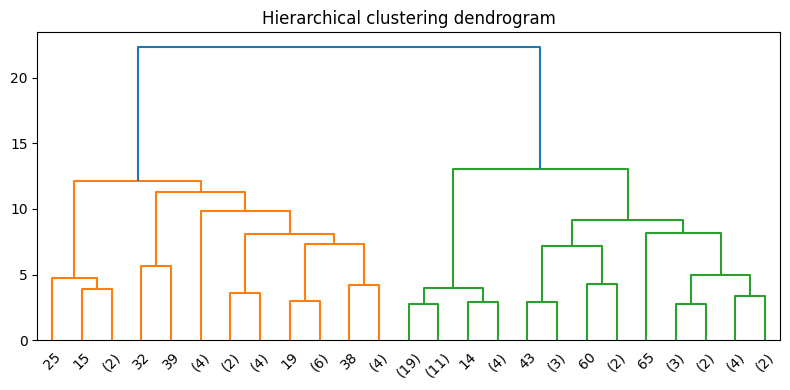

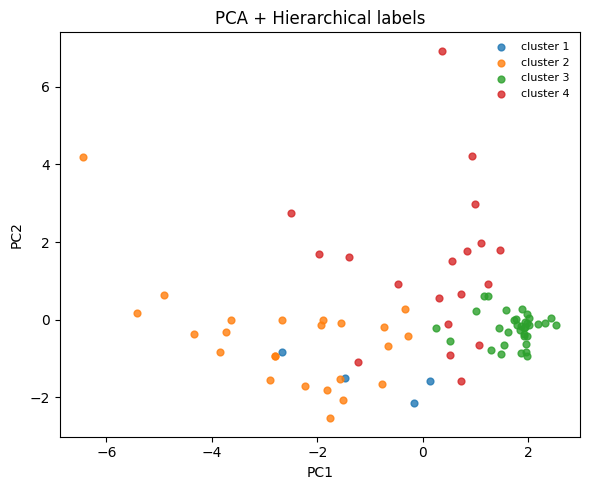

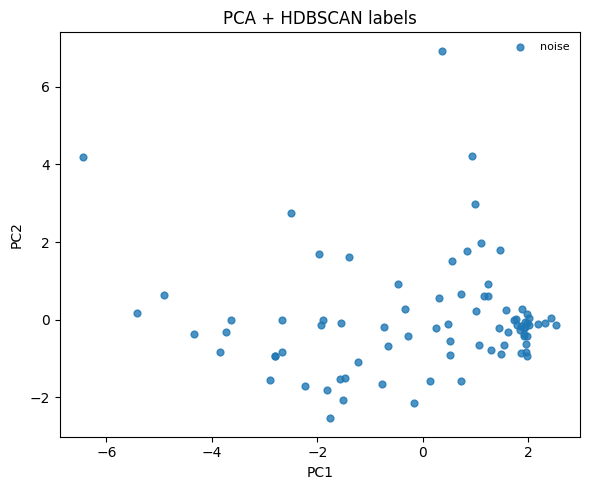

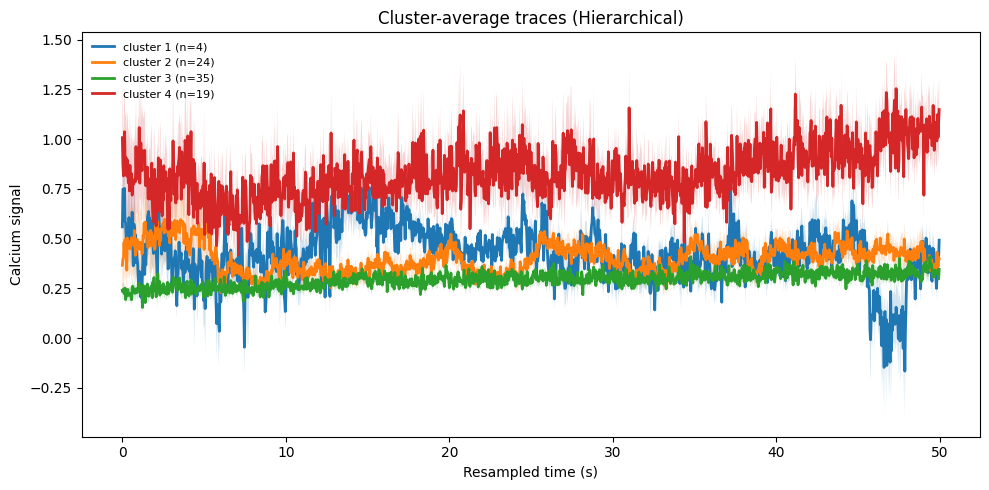

No clusters with enough traces to plot.


In [9]:
# -------------------------
# Plots
# -------------------------

print('PCA explained variance ratio:', res['pca'].explained_variance_ratio_)

plot_dendrogram(res['linkage'], truncate_mode='lastp', p=25)
plot_pca_scatter(res['Xpca'], cluster_df['hier_cluster'].to_numpy(), title='PCA + Hierarchical labels')
plot_pca_scatter(res['Xpca'], cluster_df['hdbscan_cluster'].to_numpy(), title='PCA + HDBSCAN labels')

plot_cluster_average_traces(
    traces_list,
    cluster_df['hier_cluster'].to_numpy(),
    sr=CAL_SR,
    title='Cluster-average traces (Hierarchical)',
    n_points=1500,
)

plot_cluster_average_traces(
    traces_list,
    cluster_df['hdbscan_cluster'].to_numpy(),
    sr=CAL_SR,
    title='Cluster-average traces (HDBSCAN)',
    n_points=1500,
)



In [11]:
# -------------------------
# Cluster explanation table
# -------------------------

feat_tbl = res['feature_table'].copy()
label_cols = ['hier_cluster', 'hdbscan_cluster']
feat_cols = [c for c in feat_tbl.columns if c not in ['trace_idx'] + label_cols]

def explain_clusters(df, label_col, feat_cols, top_k=6, exclude_noise=True):
    tmp = df.copy()
    if exclude_noise and (label_col == 'hdbscan_cluster'):
        tmp = tmp[tmp[label_col] != -1]
    if tmp.empty:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    med = tmp.groupby(label_col)[feat_cols].median()
    global_med = tmp[feat_cols].median()

    # Robust effect size: deviation from global median scaled by MAD
    mad = (tmp[feat_cols] - global_med).abs().median().replace(0, np.nan)
    effect = (med - global_med) / mad

    rows = []
    for cl in med.index:
        ranked = effect.loc[cl].abs().sort_values(ascending=False)
        top_feats = ranked.index[:top_k]
        n_traces = int((tmp[label_col] == cl).sum())
        for f in top_feats:
            val = effect.loc[cl, f]
            rows.append({
                'method': label_col,
                'cluster': int(cl),
                'n_traces': n_traces,
                'feature': f,
                'cluster_median': float(med.loc[cl, f]),
                'global_median': float(global_med[f]),
                'robust_effect': float(val) if np.isfinite(val) else np.nan,
                'abs_effect': float(abs(val)) if np.isfinite(val) else np.nan,
            })

    top_table = pd.DataFrame(rows).sort_values(['method', 'cluster', 'abs_effect'], ascending=[True, True, False])
    return med, effect, top_table

for label_col in label_cols:
    print(f'\n===== {label_col} =====')
    med, effect, top_table = explain_clusters(feat_tbl, label_col, feat_cols, top_k=6, exclude_noise=True)
    if med.empty:
        print('No clusters to explain (after filtering).')
        continue
    print('Cluster median feature values:')
    display(med)
    print('Top distinguishing features per cluster (ranked by absolute robust effect):')
    display(top_table[['method', 'cluster', 'n_traces', 'feature', 'cluster_median', 'global_median', 'robust_effect']])




===== hier_cluster =====
Cluster median feature values:


,std,skew,kurtosis,fraction_active,acf_tau_1e_s,acf_auc,psd_total_power,psd_centroid_hz,psd_entropy,psd_rel_low,psd_rel_mid,psd_rel_high
hier_cluster,,,,,,,,,,,,
1,0.246160,-0.505476,2.923870,0.041302,1.750000,2.003449,0.032603,3.649661,6.334737,0.0,0.165414,0.223395
2,0.249403,0.842280,0.804983,0.068641,1.966667,2.485148,0.039181,3.003592,5.395526,0.0,0.229106,0.106988
3,0.176347,0.159330,0.055308,0.030825,0.033333,0.689683,0.025093,7.182173,7.041978,0.0,0.038260,0.098214
4,0.523447,0.478306,0.356376,0.040556,0.150000,2.613428,0.189365,6.141952,6.860984,0.0,0.084185,0.111348


Top distinguishing features per cluster (ranked by absolute robust effect):


,method,cluster,n_traces,feature,cluster_median,global_median,robust_effect
0,hier_cluster,1,4,acf_tau_1e_s,1.750000,0.066667,50.500000
1,hier_cluster,1,4,kurtosis,2.923870,0.118650,8.769861
2,hier_cluster,1,4,psd_rel_high,0.223395,0.102308,8.649387
3,hier_cluster,1,4,skew,-0.505476,0.266103,-3.563111
4,hier_cluster,1,4,psd_centroid_hz,3.649661,6.106738,-2.000695
5,hier_cluster,1,4,psd_rel_mid,0.165414,0.087387,1.273405
6,hier_cluster,2,24,acf_tau_1e_s,1.966667,0.066667,57.000000
7,hier_cluster,2,24,fraction_active,0.068641,0.034917,3.216590
8,hier_cluster,2,24,skew,0.842280,0.266103,2.660755
9,hier_cluster,2,24,psd_centroid_hz,3.003592,6.106738,-2.526762



===== hdbscan_cluster =====
No clusters to explain (after filtering).


In [12]:
# Optional: save outputs
OUT_CSV = r"Z:\Adam-Lab-Shared\Data\Michal_Rubin\Dendrites\calcium_trace_clusters.csv"
cluster_df.to_csv(OUT_CSV, index=False)
print(f'Saved: {OUT_CSV}')

if not HDBSCAN_AVAILABLE:
    print('hdbscan is not installed in this environment. Install with: pip install hdbscan')



Saved: Z:\Adam-Lab-Shared\Data\Michal_Rubin\Dendrites\calcium_trace_clusters.csv


Explained variance per PC:


,explained_variance_ratio,cumulative_explained_variance
PC1,0.400950,0.400950
PC2,0.188601,0.589551
PC3,0.117956,0.707507
PC4,0.105160,0.812667
PC5,0.073663,0.886330
PC6,0.042827,0.929157



=== PC1: top 8 attributes by |loading| ===


,PC1,abs_loading
psd_centroid_hz,0.424685,0.424685
psd_rel_mid,-0.401175,0.401175
psd_entropy,0.371127,0.371127
fraction_active,-0.362406,0.362406
acf_tau_1e_s,-0.356260,0.356260
skew,-0.315712,0.315712
acf_auc,-0.254005,0.254005
kurtosis,-0.234375,0.234375



=== PC2: top 8 attributes by |loading| ===


...

,PC4,abs_loading
psd_rel_high,0.733171,0.733171
acf_auc,0.379088,0.379088
skew,-0.359523,0.359523
psd_entropy,0.297152,0.297152
acf_tau_1e_s,0.208086,0.208086
std,0.160725,0.160725
kurtosis,0.098599,0.098599
psd_total_power,0.097719,0.097719



=== PC5: top 8 attributes by |loading| ===


,PC5,abs_loading
fraction_active,0.441677,0.441677
psd_total_power,-0.422101,0.422101
skew,0.364866,0.364866
psd_entropy,0.353814,0.353814
psd_rel_mid,-0.343514,0.343514
psd_centroid_hz,0.255671,0.255671
acf_tau_1e_s,0.248214,0.248214
std,-0.237662,0.237662



=== PC6: top 8 attributes by |loading| ===


,PC6,abs_loading
kurtosis,0.721190,0.721190
fraction_active,-0.423465,0.423465
psd_rel_high,-0.369835,0.369835
acf_auc,0.287690,0.287690
skew,-0.166598,0.166598
psd_rel_mid,-0.143432,0.143432
std,0.103214,0.103214
psd_total_power,-0.098244,0.098244


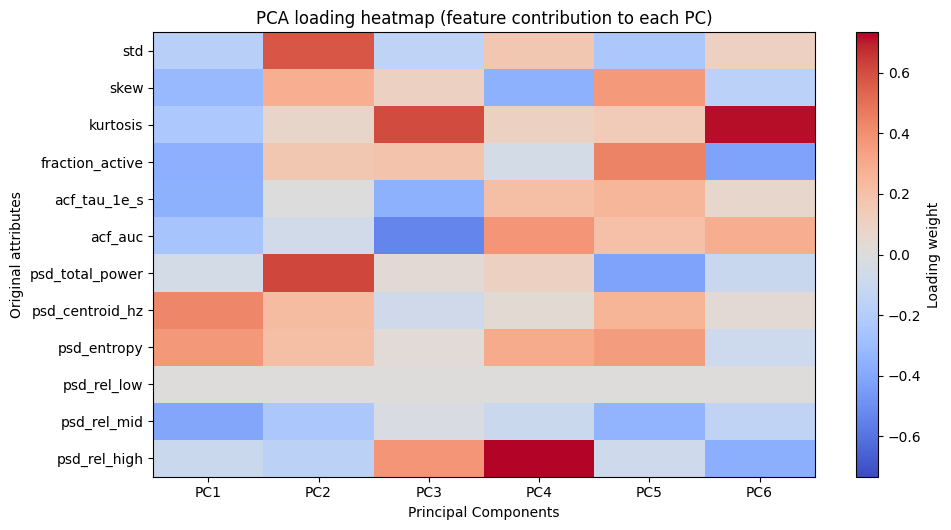

In [13]:
# -------------------------
# PCA attribute interpretation (what each PC represents)
# -------------------------

# Requires: feat_df and res from the clustering pipeline cell.
# res['pca'] is trained on standardized features.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'res' not in globals() or 'pca' not in res:
    raise RuntimeError("Run the clustering pipeline cell first (it creates 'res').")

# Prefer original feature order used in PCA
if 'feat_df' in globals() and isinstance(feat_df, pd.DataFrame):
    feat_cols = [c for c in feat_df.columns if c != 'trace_idx']
else:
    feat_tbl = res.get('feature_table', pd.DataFrame())
    drop_cols = {'trace_idx', 'hier_cluster', 'hdbscan_cluster'}
    feat_cols = [c for c in feat_tbl.columns if c not in drop_cols]

pca_model = res['pca']
components = pca_model.components_  # shape: [n_pc, n_features]

if components.shape[1] != len(feat_cols):
    raise RuntimeError(
        f"Feature count mismatch: PCA has {components.shape[1]} features, but feat_cols has {len(feat_cols)}."
    )

pc_names = [f'PC{i+1}' for i in range(components.shape[0])]
loading_df = pd.DataFrame(components.T, index=feat_cols, columns=pc_names)

evr = pd.Series(pca_model.explained_variance_ratio_, index=pc_names, name='explained_variance_ratio')
evrcum = evr.cumsum().rename('cumulative_explained_variance')

print('Explained variance per PC:')
display(pd.concat([evr, evrcum], axis=1))

TOP_K = 8
for pc in pc_names:
    print(f"\n=== {pc}: top {TOP_K} attributes by |loading| ===")
    top_idx = loading_df[pc].abs().sort_values(ascending=False).head(TOP_K).index
    display(
        loading_df.loc[top_idx, [pc]]
        .assign(abs_loading=lambda d: d[pc].abs())
        .sort_values('abs_loading', ascending=False)
    )

# Heatmap of loadings (all PCs)
fig_h = max(4, 0.45 * len(feat_cols))
fig, ax = plt.subplots(figsize=(10, fig_h))
mat = loading_df.values
v = np.nanmax(np.abs(mat)) if np.isfinite(mat).any() else 1.0
im = ax.imshow(mat, aspect='auto', cmap='coolwarm', vmin=-v, vmax=v)

ax.set_xticks(np.arange(len(pc_names)))
ax.set_xticklabels(pc_names)
ax.set_yticks(np.arange(len(feat_cols)))
ax.set_yticklabels(feat_cols)
ax.set_xlabel('Principal Components')
ax.set_ylabel('Original attributes')
ax.set_title('PCA loading heatmap (feature contribution to each PC)')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Loading weight')

plt.tight_layout()
plt.show()

# Optional: save table
# loading_df.to_csv(r"Z:\Adam-Lab-Shared\Data\Michal_Rubin\Dendrites\pca_loadings.csv")


Original features: 12
Removed as redundant: 2
Remaining features: 10

Removed feature list:
['psd_centroid_hz', 'std']

Top highly-correlated feature pairs:


,feature_a,feature_b,abs_spearman_rho
1,psd_centroid_hz,psd_rel_mid,0.966522
0,std,psd_total_power,0.901197


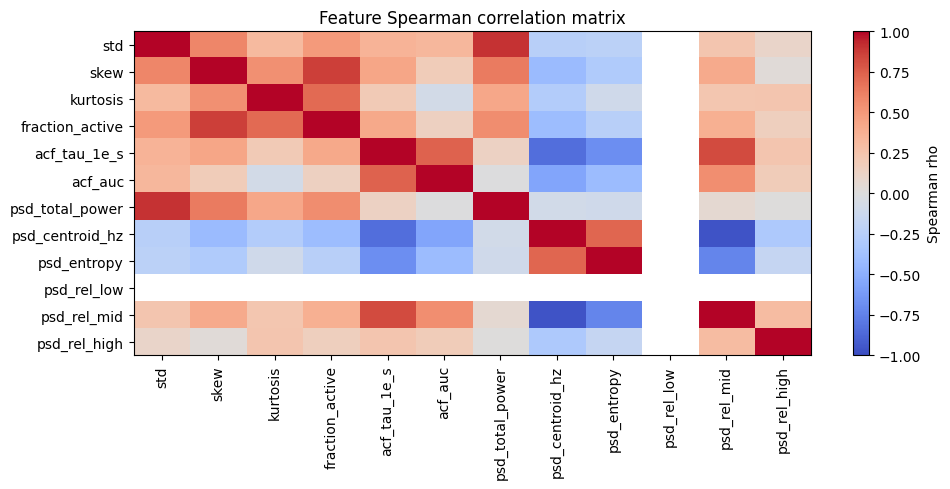


Reduced clustering done.
Hier cluster sizes (reduced):
hier_cluster
1     9
2    52
3     4
4    17
Name: count, dtype: int64

HDBSCAN cluster sizes (reduced):
hdbscan_cluster
-1    82
Name: count, dtype: int64
Adjusted Rand Index (old vs reduced): hier=0.450, hdbscan=1.000


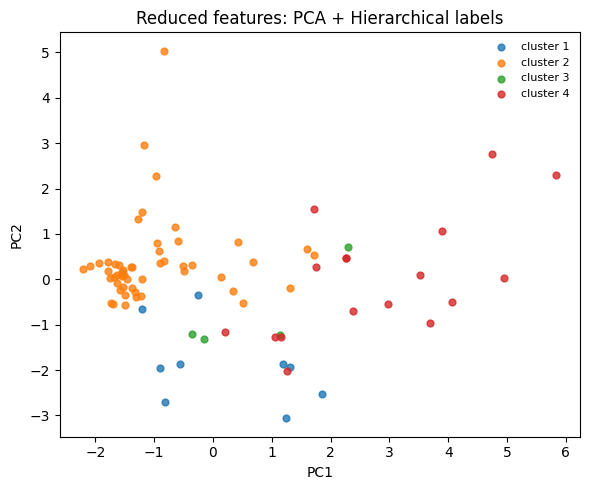

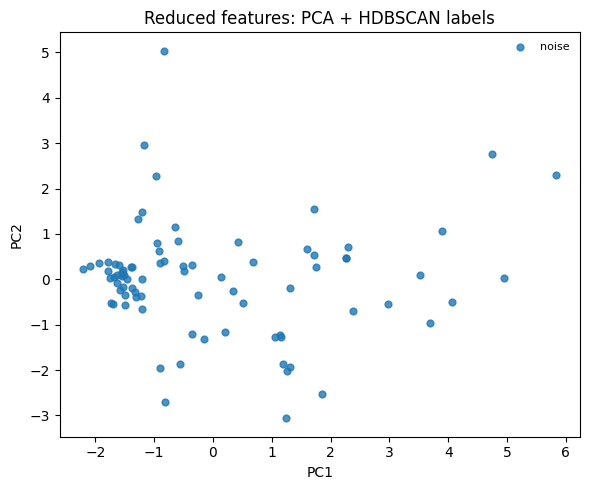

In [14]:
# -------------------------
# Feature redundancy check (Spearman) + re-clustering
# -------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score

if 'feat_df' not in globals():
    raise RuntimeError("Run the pipeline cell first (it creates 'feat_df').")

if 'run_pca_and_clustering' not in globals():
    raise RuntimeError("run_pca_and_clustering is missing. Run the function-definition cells first.")

# Tune this: features with |Spearman rho| >= threshold are considered redundant.
SPEARMAN_REDUNDANCY_THRESHOLD = 0.90
TOP_PAIRS_TO_SHOW = 30

# Build numeric feature matrix used for clustering.
base_feature_cols = [c for c in feat_df.columns if c != 'trace_idx']
X_feat = feat_df[base_feature_cols].copy()
X_feat = X_feat.replace([np.inf, -np.inf], np.nan)
X_feat = X_feat.fillna(X_feat.median(numeric_only=True))

# Spearman correlation (feature-feature)
spearman_corr = X_feat.corr(method='spearman')
abs_corr = spearman_corr.abs()

# Upper triangle for unique pairs
upper = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))

pairs = []
for col in upper.columns:
    strong = upper[col][upper[col] >= SPEARMAN_REDUNDANCY_THRESHOLD].dropna()
    for row_name, val in strong.items():
        pairs.append({'feature_a': row_name, 'feature_b': col, 'abs_spearman_rho': float(val)})

if len(pairs):
    pairs_df = pd.DataFrame(pairs).sort_values('abs_spearman_rho', ascending=False)
else:
    pairs_df = pd.DataFrame(columns=['feature_a', 'feature_b', 'abs_spearman_rho'])

# Greedy drop rule:
# For each highly-correlated pair, drop the more globally redundant feature
# (larger mean absolute Spearman correlation to all other features).
mean_abs_corr = abs_corr.mean(axis=1)

to_drop = set()
for _, row in pairs_df.iterrows():
    a = row['feature_a']
    b = row['feature_b']
    if a in to_drop or b in to_drop:
        continue
    ma = mean_abs_corr[a]
    mb = mean_abs_corr[b]
    if ma > mb:
        to_drop.add(a)
    elif mb > ma:
        to_drop.add(b)
    else:
        # deterministic tie-break
        to_drop.add(sorted([a, b])[-1])

reduced_feature_cols = [c for c in base_feature_cols if c not in to_drop]

print(f"Original features: {len(base_feature_cols)}")
print(f"Removed as redundant: {len(to_drop)}")
print(f"Remaining features: {len(reduced_feature_cols)}")

if len(to_drop):
    print()
    print("Removed feature list:")
    print(sorted(to_drop))

print()
print("Top highly-correlated feature pairs:")
if len(pairs_df):
    display(pairs_df.head(TOP_PAIRS_TO_SHOW))
else:
    print(f"No feature pairs found with |Spearman rho| >= {SPEARMAN_REDUNDANCY_THRESHOLD:.2f}")

# Optional heatmap for inspection
fig_h = max(5, 0.35 * len(base_feature_cols))
fig, ax = plt.subplots(figsize=(10, fig_h))
im = ax.imshow(spearman_corr.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(np.arange(len(base_feature_cols)))
ax.set_yticks(np.arange(len(base_feature_cols)))
ax.set_xticklabels(base_feature_cols, rotation=90)
ax.set_yticklabels(base_feature_cols)
ax.set_title('Feature Spearman correlation matrix')
plt.colorbar(im, ax=ax, label='Spearman rho')
plt.tight_layout()
plt.show()

# Re-run clustering on reduced feature set.
feat_df_reduced = feat_df[['trace_idx'] + reduced_feature_cols].copy()

# Keep clustering settings close to your previous run.
n_hier = 4
if 'cluster_df' in globals() and isinstance(cluster_df, pd.DataFrame) and 'hier_cluster' in cluster_df.columns:
    n_hier = int(cluster_df['hier_cluster'].nunique())

res_reduced = run_pca_and_clustering(
    feat_df_reduced,
    n_pca_components=0.90,
    n_hier_clusters=n_hier,
    hdbscan_min_cluster_size=10,
    hdbscan_min_samples=3,
)

cluster_df_reduced = meta_df.merge(
    res_reduced['feature_table'],
    left_on='row_idx',
    right_on='trace_idx',
    how='inner'
)

print()
print("Reduced clustering done.")
print("Hier cluster sizes (reduced):")
print(cluster_df_reduced['hier_cluster'].value_counts().sort_index())
print()
print("HDBSCAN cluster sizes (reduced):")
print(cluster_df_reduced['hdbscan_cluster'].value_counts().sort_index())

# Optional comparison with previous labels
if 'cluster_df' in globals() and isinstance(cluster_df, pd.DataFrame):
    old = cluster_df[['trace_idx', 'hier_cluster', 'hdbscan_cluster']].rename(
        columns={'hier_cluster': 'hier_old', 'hdbscan_cluster': 'hdb_old'}
    )
    new = cluster_df_reduced[['trace_idx', 'hier_cluster', 'hdbscan_cluster']].rename(
        columns={'hier_cluster': 'hier_new', 'hdbscan_cluster': 'hdb_new'}
    )
    cmp_df = old.merge(new, on='trace_idx', how='inner')

    if len(cmp_df):
        ari_hier = adjusted_rand_score(cmp_df['hier_old'], cmp_df['hier_new'])
        ari_hdb = adjusted_rand_score(cmp_df['hdb_old'], cmp_df['hdb_new'])
        print(f"Adjusted Rand Index (old vs reduced): hier={ari_hier:.3f}, hdbscan={ari_hdb:.3f}")

# Quick PCA scatter for reduced model
plot_pca_scatter(res_reduced['Xpca'], cluster_df_reduced['hier_cluster'].to_numpy(), title='Reduced features: PCA + Hierarchical labels')
plot_pca_scatter(res_reduced['Xpca'], cluster_df_reduced['hdbscan_cluster'].to_numpy(), title='Reduced features: PCA + HDBSCAN labels')
